In [85]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
# Import necessary libraries
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [143]:
x_train = pd.read_csv("modified-input-training-data.csv")
y_train = pd.read_csv("modified-output-training-data.csv")
y_test = pd.read_csv("modified-output-testing-data.csv")
x_test = pd.read_csv("modified-input-testing-data.csv")
x_train.columns

Index(['Protocol', 'Fwd Packet Length Min', 'Packet Length Min',
       'Fwd IAT Mean', 'Fwd IAT Total', 'Flow IAT Mean', 'Avg Packet Size',
       'Fwd Packet Length Mean', 'Total Fwd Packets', 'Packet Length Variance',
       'Fwd Act Data Packets', 'Flow Bytes/s', 'Fwd IAT Min', 'Fwd Packets/s',
       'Flow Bytes/s.1', 'Flow Duration'],
      dtype='object')

In [216]:
x_train.columns
col =[ 'Flow Duration',
       'Fwd IAT Mean', 'Fwd IAT Total', 'Avg Packet Size',
       'Fwd Packet Length Mean', 'Total Fwd Packets', 'Packet Length Variance',
       'Fwd Act Data Packets'
       ]


**LOGISTIC REGRESSION**

In [151]:
from sklearn.linear_model import LogisticRegression

In [238]:
lr = LogisticRegression()
model = lr.fit(x_train[col],y_train.squeeze())

In [239]:
lr_y_pred = model.predict(x_test[col])

In [240]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
#0-.benign 1-> attack

Accuracy: 0.9438470728793309
Confusion Matrix:
 [[1241   23]
 [ 118 1129]]
Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.98      0.95      1264
           1       0.98      0.91      0.94      1247

    accuracy                           0.94      2511
   macro avg       0.95      0.94      0.94      2511
weighted avg       0.95      0.94      0.94      2511



In [241]:
model.intercept_

array([1.57234715])

VISUALIZATION

<Axes: >

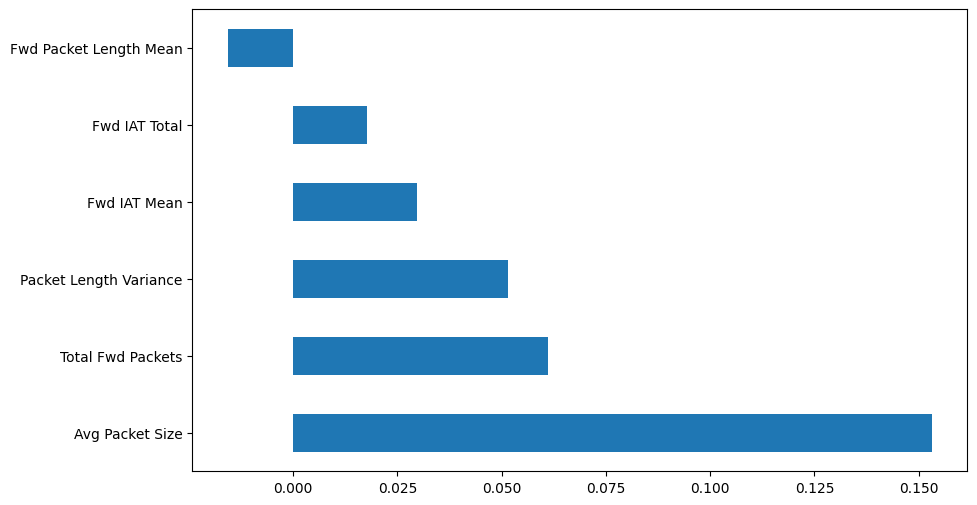

In [264]:
#FEATURE IMPORTANCE
from sklearn.inspection import permutation_importance
res = permutation_importance(model,x_test[col],y_test,n_repeats=5,random_state = 42)
importance = pd.Series( res.importances_mean ,index = x_test[col].columns).sort_values(ascending=False)
importance.head(10).plot(kind='barh' ,figsize=(10,6))

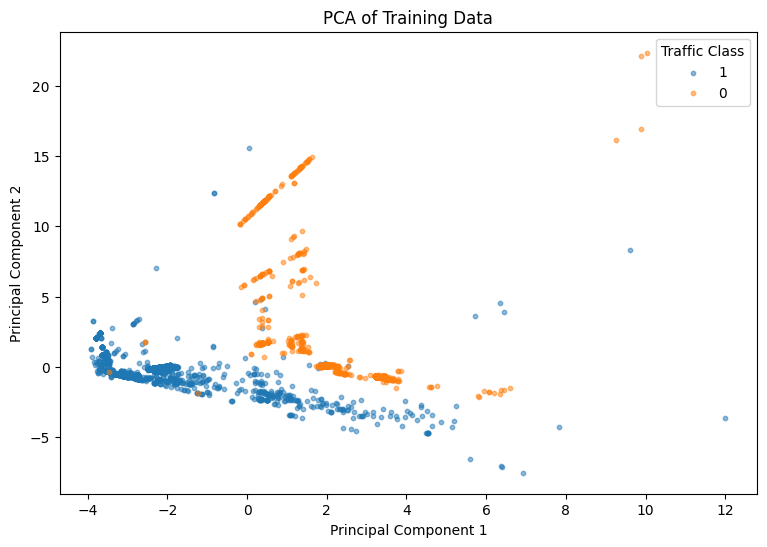

Explained variance: [0.42266254 0.1923927 ]
Total: 0.6150552454731228


In [243]:

from sklearn.decomposition import PCA

pca = PCA(n_components=2)
x_2d = pca.fit_transform(x_train)

# Convert labels into numeric codes
colors, labels = pd.factorize(y_train.squeeze())

plt.figure(figsize=(9, 6))

for i, label in enumerate(labels):
    mask = colors == i
    plt.scatter(
        x_2d[mask, 0],
        x_2d[mask, 1],
        label=label,
        alpha=0.5,
        s=10
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA of Training Data")
plt.legend(title="Traffic Class")
plt.show()
print('Explained variance:', pca.explained_variance_ratio_)
print('Total:', pca.explained_variance_ratio_.sum())

C:\Users\91959\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


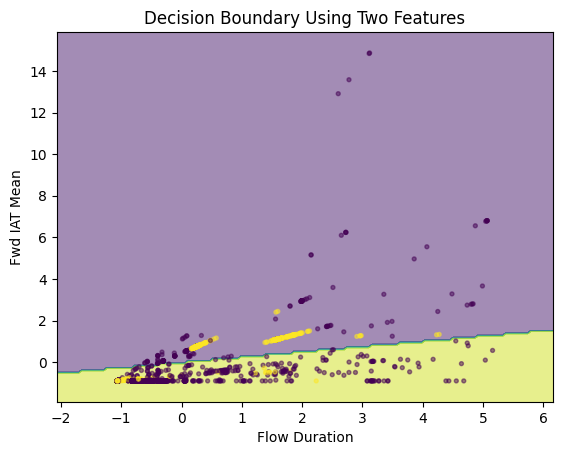

In [244]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.inspection import DecisionBoundaryDisplay
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
features = ['Flow Duration',
 'Fwd IAT Mean']

X_two = x_train[features]

# Example: fit a separate model for visualization
viz_model = LogisticRegression()
viz_model.fit(X_two, y_train)

DecisionBoundaryDisplay.from_estimator(
        viz_model,
        X_two,
        response_method='predict',
        alpha=0.5,
        grid_resolution=160
)

plt.scatter(
        X_two.iloc[:, 0],
        X_two.iloc[:, 1],
        c =pd.factorize(y_train.squeeze())[0],
        s=8,
        alpha=0.5
)

plt.xlabel(features[0])
plt.ylabel(features[1])
plt.title('Decision Boundary Using Two Features')
plt.show()

**K NEAREST NEIGHBORS**

In [300]:
col =[
 # 'Fwd Packet Length Min', 
    'Packet Length Min',
       #  'Fwd IAT Total', 'Flow IAT Mean', 
       # 'Total Fwd Packets',
      'Flow Bytes/s', 
    # 'Fwd IAT Min', 
    #    'Flow Duration'
 ]
x_train.columns

Index(['Protocol', 'Fwd Packet Length Min', 'Packet Length Min',
       'Fwd IAT Mean', 'Fwd IAT Total', 'Flow IAT Mean', 'Avg Packet Size',
       'Fwd Packet Length Mean', 'Total Fwd Packets', 'Packet Length Variance',
       'Fwd Act Data Packets', 'Flow Bytes/s', 'Fwd IAT Min', 'Fwd Packets/s',
       'Flow Bytes/s.1', 'Flow Duration'],
      dtype='object')

In [301]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)
model = knn.fit(x_train[col],y_train)
knn_y_pred = model.predict(x_test[col])

C:\Users\91959\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


In [302]:
print("Accuracy:", accuracy_score(y_test, knn_y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, knn_y_pred))
print("Classification Report:\n", classification_report(y_test, knn_y_pred))

Accuracy: 0.6451612903225806
Confusion Matrix:
 [[1263    1]
 [ 890  357]]
Classification Report:
               precision    recall  f1-score   support

           0       0.59      1.00      0.74      1264
           1       1.00      0.29      0.44      1247

    accuracy                           0.65      2511
   macro avg       0.79      0.64      0.59      2511
weighted avg       0.79      0.65      0.59      2511



VISUALIZATION

<Axes: >

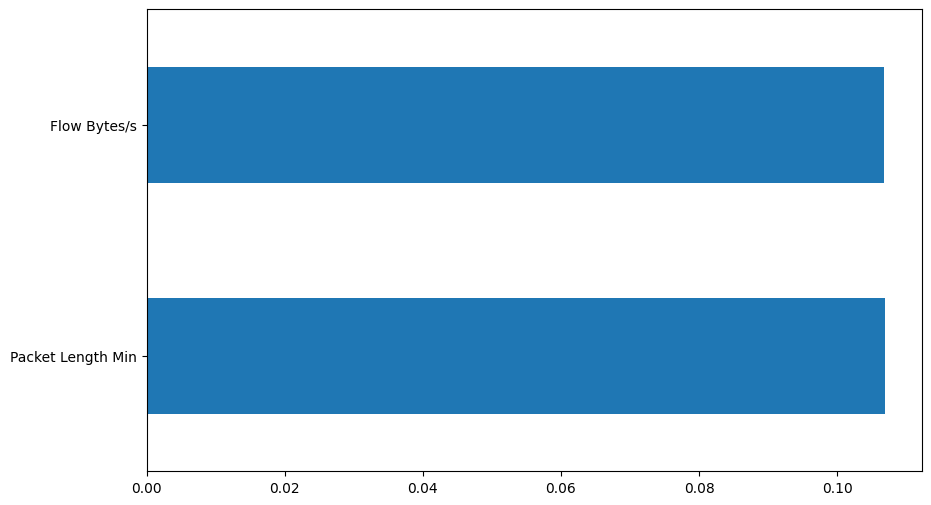

In [303]:
res = permutation_importance(model,x_test[col],y_test,n_repeats=5,random_state=42)
importance =pd.Series(res.importances_mean,index=x_test[col].columns).sort_values(ascending = False)
importance.head(10).plot(kind='barh', figsize=(10,6))

<Axes: >

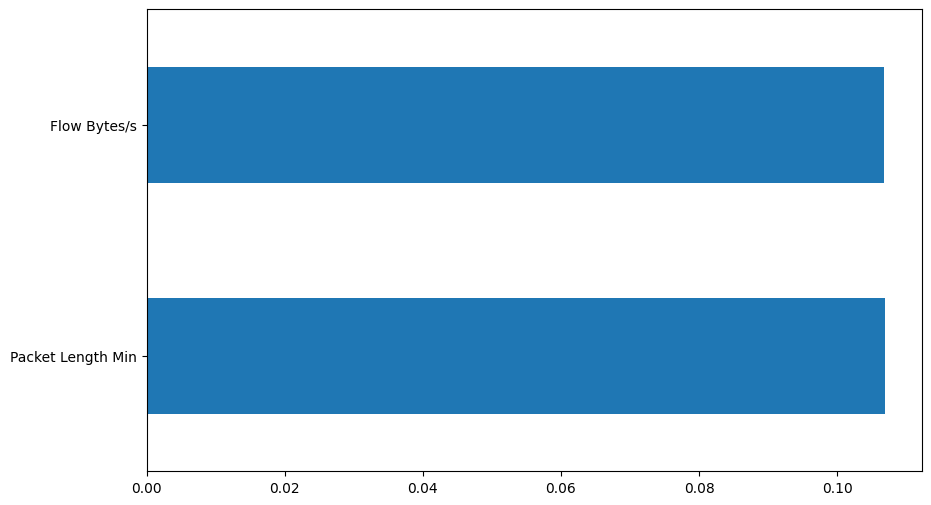

In [305]:
res = permutation_importance(model,x_test[col],y_test,n_repeats=5,random_state = 42)
importance = pd.Series( res.importances_mean ,index = x_test[col].columns).sort_values(ascending=False)
importance.head(10).plot(kind='barh' ,figsize=(10,6))

SVM-Support Vector Machine